# Bulding the components of a single session training pipeline

Need parts:

- [ ] Data Loader (from H5py)
- [ ] Metadata handler (from bpod file)
- [ ] Train/Test trial splitter (based on bpod trial numbers, and then use this so subselect trials from the H5py)
- [ ] Model (the autoencoder class)
- [ ] Training class (loss function, optimizer, checkpointing, scheduler, etc..)
- [ ] Evaluation class (load trained model, run on test set, compute metrics, save latents, ...)

This I have done for a single class already, but maybe would want to refactor it for later sessions:
- [ ] Session data preprocessing to move from .mp4-s to .h5py and crop/resize frames.

A few important notes:
- I want to make sure that there things are well modularized, and that all configs are stored neatly.
- I want to have a 'local' vs 'aws' mode, that will easily switch between local development and training on AWS.

In [7]:
import json
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import h5py
import pandas as pd

import sys
sys.path.append('/home/kurgyis/Research/VideoAnalysisTools/src/')
from behavioral_autoencoder.models import AutoEncoder

In [58]:
animal = 'kd115'
session = 'kd115_twNew_20221206_115814'

metadata_config = {
    'bpod_folder': {'local': '/home/kurgyis/Research/SpatialTranscriptomics/data/2p/', 'aws': None},
    'h5_folder': {'local': '/home/kurgyis/Research/VideoAnalysisTools/data/', 'aws': None},
    'behavior_channel_map' : {
        'outcome': 0,
        'trial_type': 1,
        'early_lick_sample': 2,
        'early_lick_delay': 3,
        'airpuff': 4,
        'autowater': 5,
        'water_volume': 6,
        'trial_length': 7,
        'z_pos': 8,
        'laser_power': 9,
        'n_licks': 11,
        'protocol': 12,
        'reaction_time': 14,
        'sample_start': 15,
        'delay_start': 16,
        'go_time': 17,
        'reward_time': 18,
        'freewater_outcome': 19,
        'reward1': 20,
    },
    'stratification_columns' : ['outcome', 'trial_type', 'airpuff'],
    'split_random_seed': 42
}

bpod_path = metadata_config['bpod_folder']['local'] + '%s/%s.bpod.npy' % (animal, session)

bpod_data = np.load(bpod_path, allow_pickle=True)

bpod_data

array([array([[1.    , 1.    , 1.    , ..., 1.    , 1.    , 6.    ],
              [1.    , 0.    , 0.    , ..., 0.    , 1.    , 0.    ],
              [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
              ...,
              [4.9156, 5.0019, 4.8789, ..., 5.3667, 5.0761, 0.    ],
              [0.    , 0.    , 0.    , ..., 1.    , 1.    , 0.    ],
              [4.9156, 5.0019, 4.8789, ..., 0.    , 0.    , 0.    ]],
             shape=(21, 459), dtype=float32)                         ,
       list(['', '', '', '', '', '', '', '', '', '', '', '', '', '', 'trial_00001.tif', 'trial_00003.tif', 'trial_00005.tif', 'trial_00007.tif', 'trial_00009.tif', 'trial_00011.tif', 'trial_00013.tif', 'trial_00015.tif', 'trial_00017.tif', 'trial_00019.tif', 'trial_00021.tif', 'trial_00023.tif', 'trial_00025.tif', 'trial_00027.tif', 'trial_00029.tif', 'trial_00031.tif', 'trial_00033.tif', 'trial_00035.tif', 'trial_00037.tif', 'trial_00039.tif', 'trial_00041.tif', 'trial_00043.tif', 'trial_0

In [46]:
behavior_array = bpod_data[0]
video_files_list = bpod_data[2]
video_trial_ids = []
for video_file in video_files_list:
    if len(video_file[0]) > 0:
        video_trial_ids.append(int(video_file[0].split('_trial')[1].split('_date')[0]))
    else:
        video_trial_ids.append(None)
video_trial_ids = pd.Series(video_trial_ids, dtype='Int64')

behavior_df = pd.DataFrame({name: behavior_array[idx,:] for name, idx in metadata_config['behavior_channel_map'].items()})
behavior_df['trial_id'] = behavior_df.index
behavior_df['video_trial_id'] = video_trial_ids

In [47]:
behavior_df[:20]

,outcome,trial_type,early_lick_sample,early_lick_delay,airpuff,autowater,water_volume,trial_length,z_pos,laser_power,...,protocol,reaction_time,sample_start,delay_start,go_time,reward_time,freewater_outcome,reward1,trial_id,video_trial_id
0,1.0,1.0,0.0,0.0,0.0,1.0,0.0651,0.0000,0.0,0.000000,...,5.0,10.0000,1.5500,2.6800,0.0000,4.9156,0.0,4.9156,0,<NA>
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0651,0.0000,0.0,0.000000,...,5.0,10.0000,1.5500,2.6800,0.0000,5.0019,0.0,5.0019,1,<NA>
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0476,0.0000,0.0,0.000000,...,5.0,0.1739,1.5500,2.6800,4.6950,4.8789,0.0,4.8789,2,<NA>
3,2.0,0.0,0.0,0.0,1.0,0.0,0.0000,0.0000,0.0,0.000000,...,5.0,0.6399,1.5500,2.6800,4.6950,0.0000,0.0,0.0000,3,<NA>
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0476,0.0000,0.0,0.000000,...,5.0,0.1981,1.5500,2.6800,4.6950,4.9031,0.0,4.9031,4,<NA>
5,2.0,1.0,0.0,0.0,1.0,0.0,0.0000,0.0000,0.0,0.000000,...,5.0,0.2517,1.5500,2.6800,4.6950,0.0000,0.0,0.0000,5,<NA>
6,1.0,1.0,0.0,0.0,0.0,0.0,0.0476,0.0000,0.0,0.000000,...,5.0,10.0000,1.5500,2.6800,4.6950,5.1649,0.0,5.1649,6,<NA>
7,2.0,1.0,0.0,0.0,1.0,0.0,0.0000,0.0000,0.0,0.000000,...,5.0,0.2496,1.5500,2.6800,4.6950,0.0000,0.0,0.0000,7,<NA>
8,1.0,1.0,1.0,1.0,0.0,0.0,0.0476,0.0000,0.0,0.000000,...,5.0,1.1022,4.3022,5.5907,7.6057,7.7590,0.0,7.7590,8,<NA>
9,1.0,1.0,0.0,0.0,0.0,0.0,0.0476,0.0000,0.0,0.000000,...,5.0,1.2372,1.5500,2.6800,4.6950,5.1448,0.0,5.1448,9,<NA>


In [48]:
np.unique(behavior_df['protocol'])

array([5., 6., 7.], dtype=float32)

In [49]:
def get_trial_filter_mask(df):
    return (df['protocol'] == 5) & (df['outcome'] < 3) & (df['early_lick_sample'] == 0) & (df['early_lick_delay'] == 0) & (df['autowater'] == 0)

In [50]:
h5_session_path = metadata_config['h5_folder']['local'] + '%s/%s_side.h5' % (session, session)

dataset = h5py.File(h5_session_path, 'r')

In [51]:
available_video_trials = np.unique(dataset['trial_ids'])

In [52]:
behavior_df['video_available'] = behavior_df['video_trial_id'].isin(available_video_trials)
behavior_df[:20]

,outcome,trial_type,early_lick_sample,early_lick_delay,airpuff,autowater,water_volume,trial_length,z_pos,laser_power,...,reaction_time,sample_start,delay_start,go_time,reward_time,freewater_outcome,reward1,trial_id,video_trial_id,video_available
0,1.0,1.0,0.0,0.0,0.0,1.0,0.0651,0.0000,0.0,0.000000,...,10.0000,1.5500,2.6800,0.0000,4.9156,0.0,4.9156,0,<NA>,False
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0651,0.0000,0.0,0.000000,...,10.0000,1.5500,2.6800,0.0000,5.0019,0.0,5.0019,1,<NA>,False
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0476,0.0000,0.0,0.000000,...,0.1739,1.5500,2.6800,4.6950,4.8789,0.0,4.8789,2,<NA>,False
3,2.0,0.0,0.0,0.0,1.0,0.0,0.0000,0.0000,0.0,0.000000,...,0.6399,1.5500,2.6800,4.6950,0.0000,0.0,0.0000,3,<NA>,False
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0476,0.0000,0.0,0.000000,...,0.1981,1.5500,2.6800,4.6950,4.9031,0.0,4.9031,4,<NA>,False
5,2.0,1.0,0.0,0.0,1.0,0.0,0.0000,0.0000,0.0,0.000000,...,0.2517,1.5500,2.6800,4.6950,0.0000,0.0,0.0000,5,<NA>,False
6,1.0,1.0,0.0,0.0,0.0,0.0,0.0476,0.0000,0.0,0.000000,...,10.0000,1.5500,2.6800,4.6950,5.1649,0.0,5.1649,6,<NA>,False
7,2.0,1.0,0.0,0.0,1.0,0.0,0.0000,0.0000,0.0,0.000000,...,0.2496,1.5500,2.6800,4.6950,0.0000,0.0,0.0000,7,<NA>,False
8,1.0,1.0,1.0,1.0,0.0,0.0,0.0476,0.0000,0.0,0.000000,...,1.1022,4.3022,5.5907,7.6057,7.7590,0.0,7.7590,8,<NA>,False
9,1.0,1.0,0.0,0.0,0.0,0.0,0.0476,0.0000,0.0,0.000000,...,1.2372,1.5500,2.6800,4.6950,5.1448,0.0,5.1448,9,<NA>,False


In [53]:
filtered_behavior_df = behavior_df[get_trial_filter_mask(behavior_df) & behavior_df['video_available']]
filtered_behavior_df[:20]

,outcome,trial_type,early_lick_sample,early_lick_delay,airpuff,autowater,water_volume,trial_length,z_pos,laser_power,...,reaction_time,sample_start,delay_start,go_time,reward_time,freewater_outcome,reward1,trial_id,video_trial_id,video_available
14,1.0,1.0,0.0,0.0,0.0,0.0,0.0476,10.2809,0.0,29.0,...,10.0000,1.55,2.68,4.695,4.9588,0.0,4.9588,14,15,True
16,1.0,1.0,0.0,0.0,0.0,0.0,0.0476,10.2629,0.0,29.0,...,10.0000,1.55,2.68,4.695,4.9532,0.0,4.9532,16,17,True
18,1.0,1.0,0.0,0.0,0.0,0.0,0.0476,10.2030,0.0,29.0,...,10.0000,1.55,2.68,4.695,4.8013,0.0,4.8013,18,19,True
20,1.0,1.0,0.0,0.0,0.0,0.0,0.0476,10.2073,0.0,29.0,...,10.0000,1.55,2.68,4.695,4.8075,0.0,4.8075,20,21,True
22,1.0,0.0,0.0,0.0,0.0,0.0,0.0476,10.9010,0.0,29.0,...,0.1402,1.55,2.68,4.695,5.3470,0.0,4.8852,22,23,True
24,2.0,1.0,0.0,0.0,1.0,0.0,0.0000,11.5814,0.0,29.0,...,0.2364,1.55,2.68,4.695,0.0000,0.0,0.0000,24,25,True
26,1.0,1.0,0.0,0.0,0.0,0.0,0.0476,10.9379,0.0,29.0,...,1.4341,1.55,2.68,4.695,5.1518,0.0,5.1518,26,27,True
28,1.0,0.0,0.0,0.0,0.0,0.0,0.0476,10.3488,0.0,29.0,...,0.1158,1.55,2.68,4.695,4.8208,0.0,4.8208,28,29,True
30,1.0,1.0,0.0,0.0,0.0,0.0,0.0476,10.2410,0.0,29.0,...,10.0000,1.55,2.68,4.695,4.8146,0.0,4.8146,30,31,True
32,2.0,1.0,0.0,0.0,0.0,0.0,0.0000,11.4407,0.0,29.0,...,0.2457,1.55,2.68,4.695,0.0000,0.0,0.0000,32,33,True


In [59]:
from sklearn.model_selection import train_test_split

# Ensure we have a copy to avoid SettingWithCopyWarning
filtered_behavior_df = filtered_behavior_df.copy()

# Get the indices of the train and test splits
train_idx, test_idx = train_test_split(
    filtered_behavior_df.index, 
    test_size=0.5, 
    random_state=metadata_config['split_random_seed'], 
    stratify=filtered_behavior_df[metadata_config['stratification_columns']]
)

# Assign 1 for training set, 2 for testing set
filtered_behavior_df['train_split'] = 0
filtered_behavior_df.loc[train_idx, 'train_split'] = 1
filtered_behavior_df.loc[test_idx, 'train_split'] = 2

# Verify the changes
filtered_behavior_df[metadata_config['stratification_columns'] + ['train_split']][:20]

,outcome,trial_type,airpuff,train_split
14,1.0,1.0,0.0,2
16,1.0,1.0,0.0,1
18,1.0,1.0,0.0,1
20,1.0,1.0,0.0,1
22,1.0,0.0,0.0,1
24,2.0,1.0,1.0,2
26,1.0,1.0,0.0,2
28,1.0,0.0,0.0,2
30,1.0,1.0,0.0,1
32,2.0,1.0,0.0,1


In [60]:
video_train_test_split_df = filtered_behavior_df[metadata_config['stratification_columns'] + ['train_split', 'video_trial_id', 'trial_id']]
video_train_test_split_df[:20]

,outcome,trial_type,airpuff,train_split,video_trial_id,trial_id
14,1.0,1.0,0.0,2,15,14
16,1.0,1.0,0.0,1,17,16
18,1.0,1.0,0.0,1,19,18
20,1.0,1.0,0.0,1,21,20
22,1.0,0.0,0.0,1,23,22
24,2.0,1.0,1.0,2,25,24
26,1.0,1.0,0.0,2,27,26
28,1.0,0.0,0.0,2,29,28
30,1.0,1.0,0.0,1,31,30
32,2.0,1.0,0.0,1,33,32


In [55]:
len(filtered_behavior_df)

166

In [62]:
import numpy as np
import pandas as pd
import h5py
from sklearn.model_selection import train_test_split

class SessionMetadataHandler:
    def __init__(self, config, mode='local', animal=None, session=None):
        """
        Initializes the handler with a configuration dictionary, running mode ('local' or 'aws'),
        and session identifiers.
        """
        self.config = config
        self.mode = mode
        self.animal = animal
        self.session = session
        
        # State variables
        self.bpod_data = None
        self.behavior_df = None
        self.filtered_behavior_df = None
        self.video_train_test_split_df = None
        
        # Store paths
        self.bpod_path = f"{self.config['bpod_folder'][self.mode]}{self.animal}/{self.session}.bpod.npy"
        self.h5_path = f"{self.config['h5_folder'][self.mode]}{self.session}/{self.session}_side.h5"

    def load_files(self):
        """Loads bpod dataset lazily from disk."""
        self.bpod_data = np.load(self.bpod_path, allow_pickle=True)

    def build_behavior_df(self):
        """Extracts the behavior trials and aligns them with video trials."""
        behavior_array = self.bpod_data[0]
        video_files_list = self.bpod_data[2]
        
        video_trial_ids = []
        for video_file in video_files_list:
            if len(video_file[0]) > 0:
                video_trial_ids.append(int(video_file[0].split('_trial')[1].split('_date')[0]))
            else:
                video_trial_ids.append(None)
        
        video_trial_ids = pd.Series(video_trial_ids, dtype='Int64')
        behavior_map = self.config['behavior_channel_map']
        
        self.behavior_df = pd.DataFrame({
            name: behavior_array[idx, :] for name, idx in behavior_map.items()
        })
        self.behavior_df['trial_id'] = self.behavior_df.index
        self.behavior_df['video_trial_id'] = video_trial_ids

    def filter_trials(self):
        """Determines the availability of videos in H5 and applies boolean filtering rules."""
        # Open the H5 file temporarily to read the trial IDs
        with h5py.File(self.h5_path, 'r') as h5_dataset:
            available_video_trials = np.unique(h5_dataset['trial_ids'])
            
        self.behavior_df['video_available'] = self.behavior_df['video_trial_id'].isin(available_video_trials)
        
        df = self.behavior_df
        # You could also move these column filters into the config in the future
        mask = (df['protocol'] == 5) & \
               (df['outcome'] < 3) & \
               (df['early_lick_sample'] == 0) & \
               (df['early_lick_delay'] == 0) & \
               (df['autowater'] == 0)
               
        self.filtered_behavior_df = df[mask & df['video_available']].copy()

    def train_test_split(self):
        """Applies train/test splitting conditionally on the chosen columns."""
        strat_cols = self.config.get('stratification_columns', ['outcome', 'trial_type', 'airpuff'])
        seed = self.config.get('split_random_seed', 42)
        
        train_idx, test_idx = train_test_split(
            self.filtered_behavior_df.index, 
            test_size=0.5, 
            random_state=seed, 
            stratify=self.filtered_behavior_df[strat_cols]
        )
        
        self.filtered_behavior_df['train_split'] = 0
        self.filtered_behavior_df.loc[train_idx, 'train_split'] = 1
        self.filtered_behavior_df.loc[test_idx, 'train_split'] = 2

    def get_video_split_df(self):
        """Isolates the necessary final output columns."""
        strat_cols = self.config.get('stratification_columns', ['outcome', 'trial_type', 'airpuff'])
        cols_to_keep = strat_cols + ['train_split', 'video_trial_id', 'trial_id']
        self.video_train_test_split_df = self.filtered_behavior_df[cols_to_keep]
        return self.video_train_test_split_df
        
    def process_all(self):
        """Convenience method to execute all steps sequentially."""
        self.load_files()
        self.build_behavior_df()
        self.filter_trials()
        self.train_test_split()
        return self.get_video_split_df()

In [ ]:
handler = SessionMetadataHandler(
    config=metadata_config, 
    mode='local', 
    animal=animal, 
    session=session
)
trial_split_df = handler.process_all()
trial_split_df.head()

,outcome,trial_type,airpuff,train_split,video_trial_id,trial_id
14,1.0,1.0,0.0,2,15,14
16,1.0,1.0,0.0,1,17,16
18,1.0,1.0,0.0,1,19,18
20,1.0,1.0,0.0,1,21,20
22,1.0,0.0,0.0,1,23,22


#### Create mini local dataset for testing the latter parts of the pipeline

In [ ]:
# 1. Sample 5 trials from train and 5 from test
train_trials = trial_split_df[trial_split_df['train_split'] == 1]['video_trial_id'][:5].tolist()
test_trials = trial_split_df[trial_split_df['train_split'] == 2]['video_trial_id'][:5].tolist()
selected_trials = train_trials + test_trials

print(f"Selected train trials: {train_trials}")
print(f"Selected test trials: {test_trials}")

# 2. Define paths
h5_dir = f"{metadata_config['h5_folder']['local']}{session}/"
original_h5_path = f"{h5_dir}{session}_side.h5"
mini_h5_path = f"{h5_dir}{session}_side_mini.h5"

# 3. Create the mini dataset
print(f"Creating mini dataset at {mini_h5_path}...")
with h5py.File(original_h5_path, 'r') as src_h5, h5py.File(mini_h5_path, 'w') as dst_h5:
    
    # Load the trial_ids array to find which frames to extract
    src_trial_ids = src_h5['trial_ids'][:]
    
    # Create boolean mask and get exact indices of frames
    mask = np.isin(src_trial_ids, selected_trials)
    frame_indices = np.where(mask)[0]
    
    print(f"Total frames to extract: {len(frame_indices)}")
    
    # Iterate through each dataset in the root of the HDF5 (e.g., frames, trial_ids, filenames, etc.)
    for key in src_h5.keys():
        print(f"Extracting dataset '{key}'...")
        src_dataset = src_h5[key]
        
        # Since frame_indices is strictly increasing (from np.where), h5py can slice directly
        # and sizes are small enough (a few thousand frames) to load into memory
        subset_data = src_dataset[frame_indices]
        
        # Create corresponding dataset in the new H5 file
        dst_h5.create_dataset(
            key, 
            data=subset_data, 
            compression="lzf" if key == 'frames' else None
        )

print("Done creating mini local dataset!")

Selected train trials: [17, 19, 21, 23, 31]
Selected test trials: [15, 25, 27, 29, 35]
Creating mini dataset at /home/kurgyis/Research/VideoAnalysisTools/data/kd115_twNew_20221206_115814/kd115_twNew_20221206_115814_side_mini.h5...
Total frames to extract: 20460
Extracting dataset 'filenames'...
Extracting dataset 'frames'...
Extracting dataset 'id_within_trial'...
Extracting dataset 'trial_ids'...
Done creating mini local dataset!


In [79]:
import torch
from torch.utils.data import Dataset, DataLoader

class H5VideoDataset(Dataset):
    def __init__(self, h5_path, valid_trials_df, split='train', config=None):
        """
        Args:
            h5_path (str): Path to the HDF5 file.
            valid_trials_df (pd.DataFrame): DataFrame containing valid trials (with train_split, video_trial_id).
            split (str): 'train', 'test', or 'all'.
            config (dict): Configuration dictionary containing splitting parameters.
        """
        self.h5_path = h5_path
        self.split = split
        self.config = config or {}
        
        # Extract valid video trial IDs
        self.valid_trial_ids = valid_trials_df['video_trial_id'].dropna().unique()
        
        # The h5 file handle, initialized lazily to avoid multiprocessing issues
        self.h5_file = None
        
        # Build mapping from dataset_idx -> global_h5_idx
        self.frame_indices = self._build_frame_indices(valid_trials_df)

        self.mean_frame = 0.
        if self.config.get('subtract_mean_frame', False):
            mean_frame_path = self.config.get('mean_frame_path')
            if mean_frame_path and os.path.exists(mean_frame_path):
                self.mean_frame = np.load(mean_frame_path)
            else:
                print("Warning: mean_frame_path not provided or file does not exist. Calculating it now...")
                self.mean_frame = self._build_mean_frame(valid_trials_df)

    def _build_frame_indices(self, df):
        """
        Constructs a list of actual HDF5 indices to sample from based on config.
        """
        # Open temporarily just to read the trial IDs
        with h5py.File(self.h5_path, 'r') as h5f:
            h5_trial_ids = h5f['trial_ids'][:]
            
        split_method = self.config.get('frame_selection_method', 'frame_subsample')
        
        if split_method == 'frame_subsample':
            nth_frame = self.config.get('train_nth_frame', 10)
            
            train_indices = []
            test_indices = []
            all_indices = []
            
            # Go trial-by-trial to subsample appropriately
            for trial_id in self.valid_trial_ids:
                trial_mask = (h5_trial_ids == trial_id)
                trial_indices = np.where(trial_mask)[0]
                
                if len(trial_indices) == 0:
                    continue
                    
                # Train gets every nth frame within this trial
                t_train = trial_indices[::nth_frame]
                # Test is offset by half the nth_frame to get a different subset
                t_test = trial_indices[nth_frame//2::nth_frame]
                
                train_indices.append(t_train)
                test_indices.append(t_test)
                all_indices.append(trial_indices)
                
            train_indices = np.concatenate(train_indices) if train_indices else np.array([])
            test_indices = np.concatenate(test_indices) if test_indices else np.array([])
            all_indices = np.concatenate(all_indices) if all_indices else np.array([])
            
            if self.split == 'train':
                return train_indices
            elif self.split == 'test':
                return test_indices
            else: # 'all'
                return np.sort(all_indices)
                
        elif split_method == 'trial_split':
            # Subsample by entire trials
            if self.split == 'train':
                target_trials = df[df['train_split'] == 1]['video_trial_id'].values
            elif self.split == 'test':
                target_trials = df[df['train_split'] == 2]['video_trial_id'].values
            else:
                target_trials = df['video_trial_id'].values
                
            return np.where(np.isin(h5_trial_ids, target_trials))[0]
            
        else:
            raise ValueError(f"Unknown frame_selection_method: {split_method}")

    def _build_mean_frame(self, df):
        """Computes the mean frame across the entire dataset (or a subset) for normalization."""
        with h5py.File(self.h5_path, 'r') as h5f:
            h5_trial_ids = h5f['trial_ids'][:]
            if df is not None:
                indices = np.where(np.isin(h5_trial_ids, df['video_trial_id'].values))[0]
            else:
                indices = np.arange(len(h5_trial_ids))
            n_inds = np.minimum(len(indices), 5000)  # Limit to 5000 frames for efficiency
            subsample_indices = np.linspace(0, len(indices)-1, num=5000, dtype=int)  # Sample every 10th frame for efficiency
            mean_frame = np.mean(h5f['frames'][indices[subsample_indices]], axis=0)
        
        return torch.from_numpy(mean_frame).float() / 255.0

    def __len__(self):
        return len(self.frame_indices)

    def __getitem__(self, idx):
        # 1. LAZY LOADING for multiprocessing safety
        if self.h5_file is None:
            self.h5_file = h5py.File(self.h5_path, 'r')
        
        # 2. Map dataset index to original H5 frame index
        h5_idx = self.frame_indices[idx]
        
        # 3. Read frame from disk
        frame = self.h5_file['frames'][h5_idx]
        
        # 4. Convert and normalize -> [0.0, 1.0]
        # Make sure our bytes become float tensors
        frame_tensor = torch.from_numpy(frame).float() / 255.0
        
        return frame_tensor - self.mean_frame

In [80]:
dataset_config = {
    'frame_selection_method': 'frame_subsample',
    'train_nth_frame': 10,
    'subtract_mean_frame': True,
    'mean_frame_path': None,
}

train_dataset = H5VideoDataset(mini_h5_path, trial_split_df, split='train', config=dataset_config)
test_dataset = H5VideoDataset(mini_h5_path, trial_split_df, split='test', config=dataset_config)

print(f"Train Dataset size: {len(train_dataset)}")
print(f"Test Dataset size: {len(test_dataset)}")

# Test the dataloader with the critical 'num_workers' parameter > 0
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)

print("\nFetching first batch...")
sample_batch = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Dtype: {sample_batch.dtype}")
print(f"Min value: {sample_batch.min():.4f}, Max value: {sample_batch.max():.4f}")

Train Dataset size: 2050
Test Dataset size: 2046

Fetching first batch...
Batch shape: torch.Size([32, 1, 120, 112])
Dtype: torch.float32
Min value: -0.5536, Max value: 0.6697


In [81]:
sample_batch.shape

torch.Size([32, 1, 120, 112])

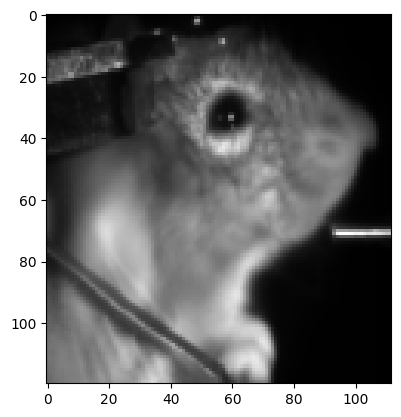

In [82]:
plt.imshow(train_dataset.mean_frame.squeeze(), cmap='gray')

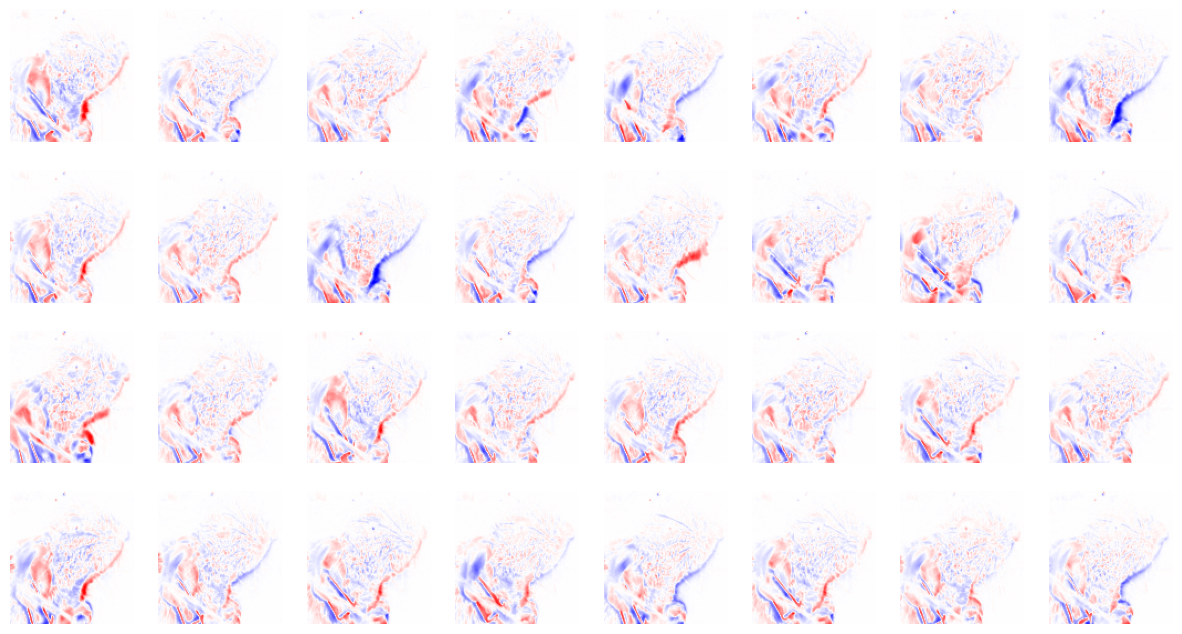

In [85]:
plt.subplots(4,8, figsize=(15,8))
for i in range(32):
    plt.subplot(4,8,i+1)
    plt.imshow(sample_batch[i].squeeze(), cmap='bwr', vmin = -0.5, vmax = 0.5)
    plt.axis('off')

## Trainer class

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

class VideoTrainer:
    def __init__(self, model, config, device=None):
        self.model = model
        self.config = config['training']
        self.model_config = config['model']
        
        # Setup Compute Device
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        
        # Core Optimization Components
        self.optimizer = AdamW(self.model.parameters(), lr=self.config['learning_rate'])
        self.mse_criterion = nn.MSELoss()
        self.latent_lambda = self.config.get('latent_lambda', 0.0)
        
        # Modular Scheduler Setup
        if self.config.get('lr_scheduler') == 'ReduceLROnPlateau':
            self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', patience=3, factor=0.5)
        else:
            self.scheduler = None
            
        os.makedirs(self.config['checkpoint_dir'], exist_ok=True)

    def compute_loss(self, x, x_recon, z):
        """
        Calculates the joint loss function: Total = MSE + lambda * L2_norm(z)
        """
        # Reconstruction loss
        recon_loss = self.mse_criterion(x_recon, x)
        
        # L2 Regularization on the latent space
        # z shape is (bs, seq_length, embed_size). Normalizing by element count.
        latent_loss = torch.mean(torch.sum(z ** 2, dim=-1))
        
        total_loss = recon_loss + (self.latent_lambda * latent_loss)
        
        return total_loss, recon_loss, latent_loss

    def train_epoch(self, dataloader):
        self.model.train()
        total_epoch_loss = 0.0
        
        for batch in dataloader:
            batch = batch.to(self.device)
            
            # Adapt 4D DataLoader batch [bs, c, h, w] to 5D Model expectation [bs, 1, c, h, w]
            if batch.dim() == 4:
                batch = batch.unsqueeze(1)
                
            self.optimizer.zero_grad()
            
            # Forward pass
            x_recon, z = self.model(batch)
            
            # Loss and backpropagation
            loss, _, _ = self.compute_loss(batch, x_recon, z)
            loss.backward()
            self.optimizer.step()
            
            total_epoch_loss += loss.item() * batch.size(0)
            
        return total_epoch_loss / len(dataloader.dataset)

    @torch.no_grad()
    def evaluate(self, dataloader):
        self.model.eval()
        total_val_loss = 0.0
        total_recon_loss = 0.0
        total_latent_loss = 0.0
        
        for batch in dataloader:
            batch = batch.to(self.device)
            if batch.dim() == 4:
                batch = batch.unsqueeze(1)
                
            x_recon, z = self.model(batch)
            loss, recon_loss, latent_loss = self.compute_loss(batch, x_recon, z)
            total_val_loss += loss.item() * batch.size(0)
            total_recon_loss += recon_loss.item() * batch.size(0)
            total_latent_loss += latent_loss.item() * batch.size(0)
            
        return total_val_loss / len(dataloader.dataset), total_recon_loss / len(dataloader.dataset), total_latent_loss / len(dataloader.dataset)

    def fit(self, train_loader, val_loader):
        best_val_loss = float('inf')
        epochs = self.config.get('epochs', 10)
        
        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch(train_loader)
            val_loss, val_recon_loss, val_latent_loss = self.evaluate(val_loader)
            
            # Adjust learning rate based on performance
            if self.scheduler is not None:
                if isinstance(self.scheduler, ReduceLROnPlateau):
                    self.scheduler.step(val_loss)
                else:
                    self.scheduler.step()
                    
            current_lr = self.optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:02d}/{epochs:02d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Val Recon Loss: {val_recon_loss:.6f} | Val Latent Loss: {val_latent_loss:.6f} | LR: {current_lr:.6e}")
            
            # Handle Checkpointing
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                checkpoint_path = os.path.join(self.config['checkpoint_dir'], 'best_model.pt')
                #torch.save({
                #    'epoch': epoch,
                #    'model_state_dict': self.model.state_dict(),
                #    'optimizer_state_dict': self.optimizer.state_dict(),
                #    'config': self.config,
                #    'val_loss': val_loss
                #}, checkpoint_path)

In [88]:
config_path = '../configs/ae_config.json'
with open(config_path, 'r') as f:
    training_config = json.load(f)

In [89]:
# Initialize Dataset and Loaders
train_dataset = H5VideoDataset(mini_h5_path, trial_split_df, split='train', config=dataset_config)
val_dataset = H5VideoDataset(mini_h5_path, trial_split_df, split='test', config=dataset_config)

train_loader = DataLoader(train_dataset, batch_size=training_config['training']['batch_size'], shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=training_config['training']['batch_size'], shuffle=False, num_workers=4)

# Initialize Model and Run Trainer
model = AutoEncoder(training_config['model'])
trainer = VideoTrainer(model, training_config)

# Begin Training Execution Loop
trainer.fit(train_loader, val_loader)

Epoch 01/50 | Train Loss: 0.013670 | Val Loss: 0.005019 | LR: 1.000000e-03
Epoch 02/50 | Train Loss: 0.004111 | Val Loss: 0.003860 | LR: 1.000000e-03
Epoch 03/50 | Train Loss: 0.003855 | Val Loss: 0.003854 | LR: 1.000000e-03
Epoch 04/50 | Train Loss: 0.003852 | Val Loss: 0.003842 | LR: 1.000000e-03
Epoch 05/50 | Train Loss: 0.003851 | Val Loss: 0.003840 | LR: 1.000000e-03
Epoch 06/50 | Train Loss: 0.003846 | Val Loss: 0.003838 | LR: 1.000000e-03
Epoch 07/50 | Train Loss: 0.003845 | Val Loss: 0.003840 | LR: 1.000000e-03
Epoch 08/50 | Train Loss: 0.003840 | Val Loss: 0.003826 | LR: 1.000000e-03


KeyboardInterrupt: 

SingleSessionDecoder(
  (linear_layer): Linear(in_features=16, out_features=13440, bias=True)
)

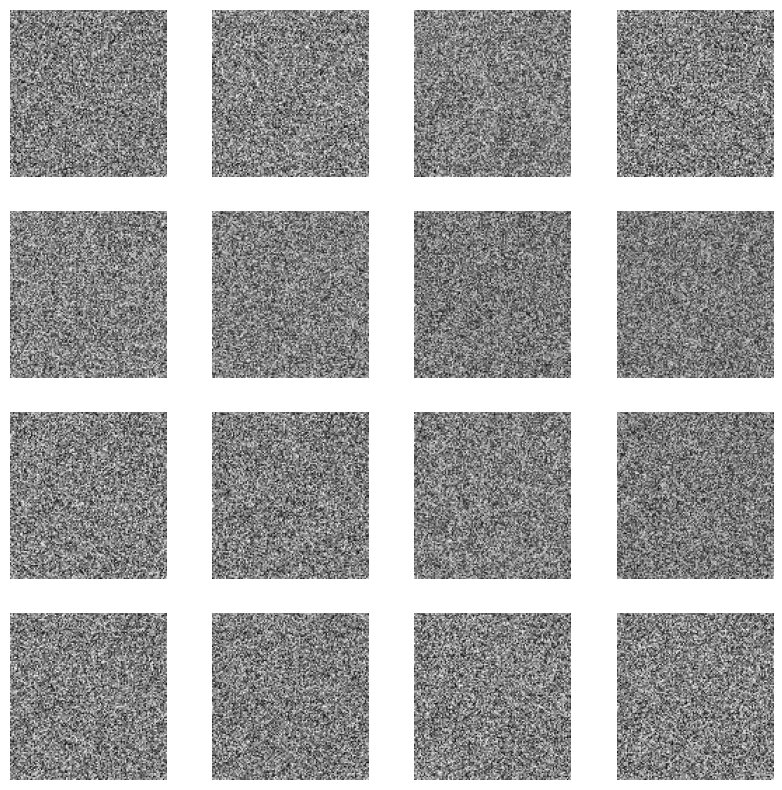

In [94]:
plt.subplots(4,4, figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    input = torch.zeros(1,1,16).to(trainer.device)
    input[0,0,i] = 1
    plt.imshow(trainer.model.decoder(input).squeeze().detach().cpu().reshape(120,112), cmap='gray')
    plt.axis('off')

trainer.model.decoder